## **Modeling and Evaluation**

This notebook runs the complete two-stage forecasting pipeline for **CA_3 – FOODS** across three departments: FOODS_1, FOODS_2, and FOODS_3.

**Stage 1** compares all candidate models — baseline, traditional statistical, and machine learning — on the same 80/20 time-based train-test split. The model with the lowest RMSE per department advances to Stage 2.

**Stage 2** tunes the Stage 1 winner using GridSearchCV with TimeSeriesSplit cross-validation (5 folds), then generates the final 28-day forecast.

Between Stage 1 and Stage 2, a cross-validation search determines the optimal number of features to use — removing zero-importance features and finding the feature count where the CV RMSE is lowest.


### **Import Libraries and Load Modeling Functions**

In [ ]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
SRC_DIR       = os.path.join(BASE_DIR, "src")

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from modeling import (
    load_and_prepare_dataset,
    show_predictors,
    time_split_dept,
    stage1_model_selection_per_dept,
    plot_forecast_vs_actual,
    get_feature_importance_for_stage1_winner,
    plot_feature_importance_all,
    get_ml_grid,
    stage2_tune_best_model_per_dept,
    forecast_next_28_days,
    forecast_next_28_days_ml_recursive,
    find_best_feature_count,
    plot_feature_count_search,
)

print("All modeling functions imported successfully.")


All modeling functions imported successfully.


### **Load and Inspect the Modeling Dataset**

The dataset loaded here is the output of the Feature Engineering step. It contains the target variable (`sales_qty`) and all 50 predictor features for FOODS_1, FOODS_2, and FOODS_3 at CA_3.

**`load_and_prepare_dataset`** - function sorts by department and date, removes any NaN or infinite values, and separates numeric predictors from the target and identifier columns.


In [ ]:
data_path = os.path.join(PROCESSED_DIR, "modeling_dataset.csv")

df, predictors, target_col, dropped_predictors = load_and_prepare_dataset(
    data_path, target_col='sales_qty'
)

print("Dataset shape:", df.shape)
print("Target:", target_col)
print()
show_predictors(predictors)

if dropped_predictors:
    print("\nDropped (non-numeric):")
    for col in dropped_predictors:
        print(" -", col)

print("\nRows per department:")
print(df.groupby('dept_id').size())


Dataset shape: (5487, 53)
Target: sales_qty

Predictor features to be used:
 - month
 - year
 - snap_CA
 - is_event
 - event_count
 - is_cultural_event
 - is_national_event
 - is_religious_event
 - is_sport_event
 - sell_price
 - lag_1
 - lag_2
 - lag_3
 - lag_7
 - lag_14
 - lag_21
 - lag_28
 - lag_42
 - lag_56
 - lag_84
 - rolling_mean_7
 - rolling_mean_14
 - rolling_mean_28
 - rolling_mean_42
 - rolling_mean_56
 - rolling_std_7
 - rolling_std_14
 - rolling_std_28
 - rolling_std_42
 - rolling_std_56
 - ewma_7
 - ewma_14
 - ewma_28
 - rolling_max_7
 - rolling_min_7
 - rolling_max_28
 - rolling_min_28
 - day_of_week
 - week_of_year
 - is_weekend
 - day_of_month
 - is_month_end
 - is_quarter_end
 - price_change_7
 - price_change_28
 - sell_price_lag_7
 - sell_price_lag_28
 - trend_index
 - snap_event_inter

Dropped (non-numeric):
 - weekday

Rows per department:
dept_id
FOODS_1    1829
FOODS_2    1829
FOODS_3    1829
dtype: int64


### **Stage 1: All Candidate Models per Department**

All models are trained on the first 80% of each department's time series and evaluated on the remaining 20%. The split is strictly time-ordered:
- **training set** - always contains the earlier dates
- **test set** - always contains the more recent dates

**Models evaluated:**

| Family / Type | Models |
|--------|--------|
| Baseline | Naive, Seasonal Naive (7-day cycle) |
| Traditional | Exponential Smoothing (add-add, add-mul), ARIMA (3 orders), SARIMA (3 orders) |
| ML | Random Forest (2 configs), XGBoost (2 configs), LightGBM (2 configs) |

All models are ranked by RMSE. The best model per department advances to Stage 2.


In [3]:
stage1_tables         = []
stage1_best_pred_list = []
stage1_best_rows      = {}

dept_ids = sorted(df['dept_id'].unique())

for dept in dept_ids:
    print(f"Running Stage 1 for {dept} ...")
    out = stage1_model_selection_per_dept(
        df=df, dept_id=dept, features=predictors,
        target_col=target_col, train_ratio=0.8
    )
    stage1_tables.append(out['dept_results_df'])
    stage1_best_pred_list.append(out['stage1_best_pred_df'])
    stage1_best_rows[dept] = out['best_stage1_row']

stage1_results_df   = pd.concat(stage1_tables, ignore_index=True)
stage1_best_pred_df = pd.concat(stage1_best_pred_list, ignore_index=True)

print("\nStage 1 complete.")
stage1_results_df


Running Stage 1 for FOODS_1 ...
FOODS_1 | ES (add,mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.
Running Stage 1 for FOODS_2 ...
FOODS_2 | ES (add,mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.
Running Stage 1 for FOODS_3 ...
FOODS_3 | ES (add,mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Stage 1 complete.


,dept_id,model_family,model_name,mae,rmse,mape
0,FOODS_1,ML,XGB_200_0.05_5,52.812369,73.939604,12.255406
1,FOODS_1,ML,XGB_100_0.1_3,52.832503,74.258052,12.091529
2,FOODS_1,ML,LGB_300_0.03_8_63,54.440263,76.867045,12.382326
3,FOODS_1,ML,LGB_200_0.05_6_31,54.724732,77.502469,12.355009
4,FOODS_1,ML,RF_100_5,56.259012,79.204060,12.839532
5,FOODS_1,ML,RF_200_10,56.467119,79.966674,12.947920
6,FOODS_1,Traditional,"SARIMA(1, 1, 2)(1,1,1,7)",62.052367,85.700397,14.270391
7,FOODS_1,Traditional,"SARIMA(2, 1, 1)(1,1,1,7)",63.869728,88.137905,14.254736
8,FOODS_1,Traditional,"SARIMA(1, 1, 1)(1,1,1,7)",68.552677,93.698260,14.844187
9,FOODS_1,Traditional,"ARIMA(1, 1, 1)",75.788332,104.672472,16.413439


### **Stage 1 Best Model per Department**

The table below shows the top-ranked model per department.
This is the baseline for comparison before tuning in Stage 2.


In [4]:
stage1_best_summary = (
    stage1_results_df
    .sort_values('rmse')
    .groupby('dept_id', as_index=False)
    .first()
)
display(stage1_best_summary)

print("\nSummary:")
for _, row in stage1_best_summary.iterrows():
    print(f"  {row['dept_id']}: {row['model_name']} — "
          f"RMSE={row['rmse']:.2f}, MAE={row['mae']:.2f}, MAPE={row['mape']:.2f}%")


,dept_id,model_family,model_name,mae,rmse,mape
0,FOODS_1,ML,XGB_200_0.05_5,52.812369,73.939604,12.255406
1,FOODS_2,ML,XGB_200_0.05_5,56.979521,73.264892,8.817227
2,FOODS_3,ML,XGB_200_0.05_5,200.798295,275.656276,77.042247



Summary:
  FOODS_1: XGB_200_0.05_5 — RMSE=73.94, MAE=52.81, MAPE=12.26%
  FOODS_2: XGB_200_0.05_5 — RMSE=73.26, MAE=56.98, MAPE=8.82%
  FOODS_3: XGB_200_0.05_5 — RMSE=275.66, MAE=200.80, MAPE=77.04%


### **Stage 1 Forecast vs Actual**

The plots below show how the Stage 1 best model tracks actual demand
on the test period. This is the demand planner's equivalent of a
forecast accuracy review chart.


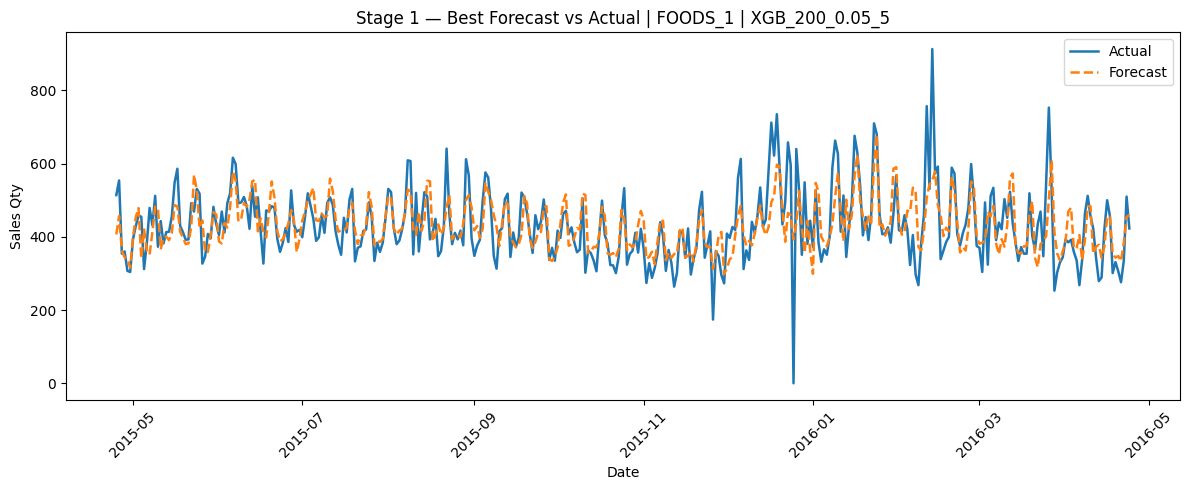

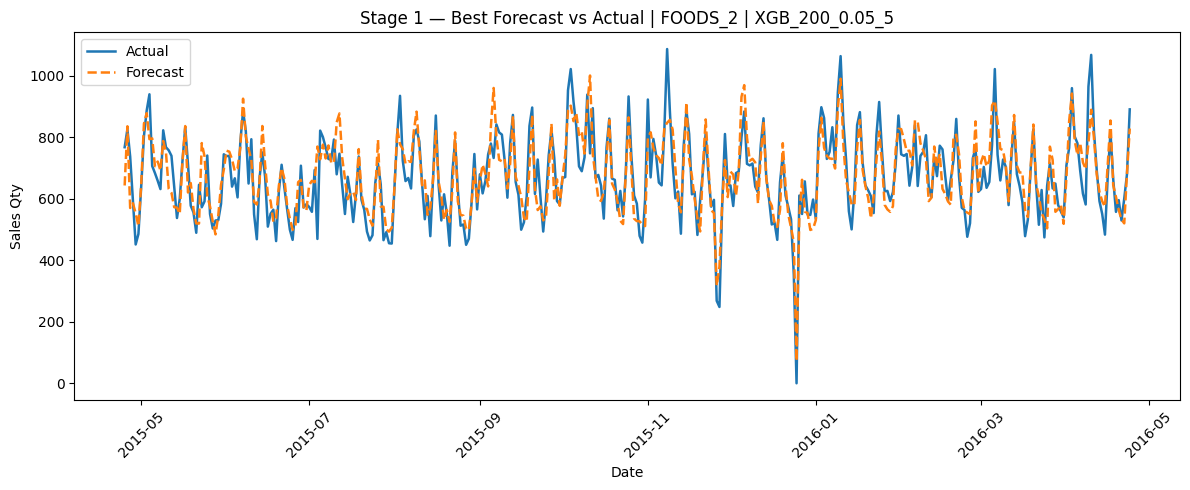

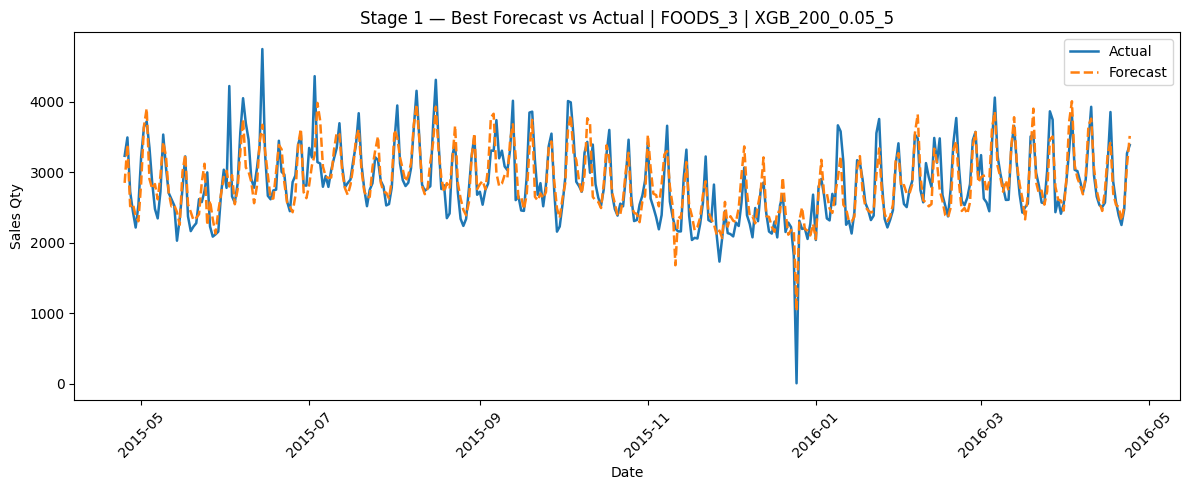

In [5]:
for dept in dept_ids:
    temp = stage1_best_pred_df[stage1_best_pred_df['dept_id']==dept].copy()
    model_name = stage1_best_rows[dept]['model_name']
    plot_forecast_vs_actual(
        temp, 'stage1_best_pred',
        f"Stage 1 — Best Forecast vs Actual | {dept} | {model_name}"
    )


### **Feature Importance — ML Models Only**

For departments where an ML model won Stage 1, feature importance scores are determined. This shows which features contributed most to the model's predictions and helps identify which inputs can be removed without losing accuracy.

Feature importance — FOODS_1 ...


,dept_id,feature,importance
0,FOODS_1,rolling_mean_7,0.163366
1,FOODS_1,day_of_week,0.107789
2,FOODS_1,lag_1,0.078669
3,FOODS_1,ewma_7,0.055883
4,FOODS_1,trend_index,0.054376
5,FOODS_1,ewma_14,0.039419
6,FOODS_1,rolling_min_7,0.031404
7,FOODS_1,is_cultural_event,0.030543
8,FOODS_1,rolling_mean_14,0.028506
9,FOODS_1,lag_28,0.026360


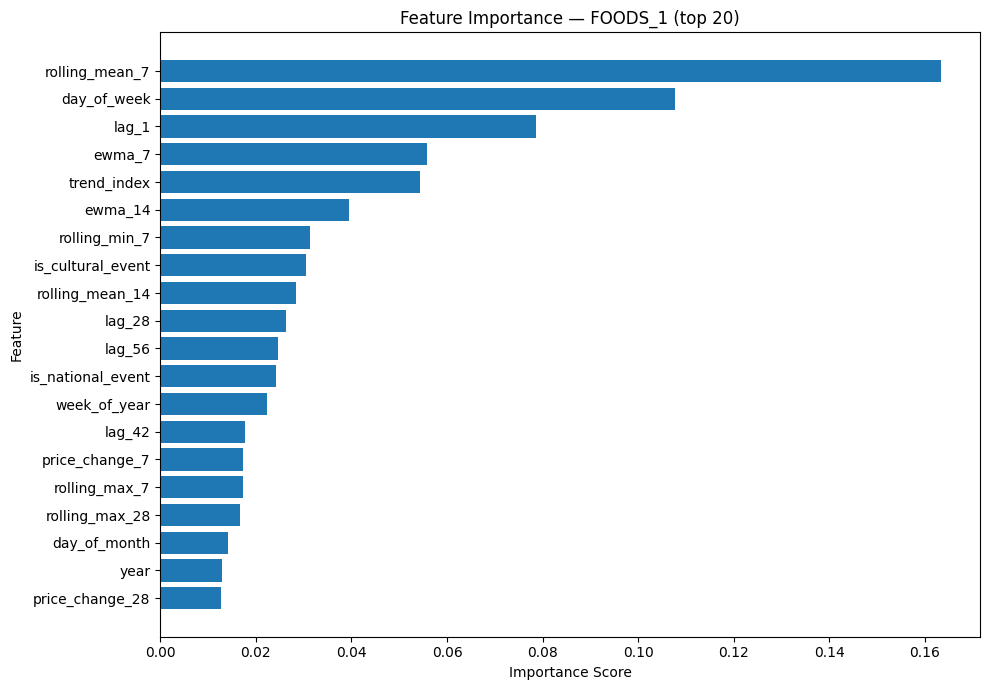

Feature importance — FOODS_2 ...


,dept_id,feature,importance
0,FOODS_2,snap_CA,0.143973
1,FOODS_2,lag_1,0.122149
2,FOODS_2,day_of_week,0.118929
3,FOODS_2,lag_28,0.073166
4,FOODS_2,day_of_month,0.055053
5,FOODS_2,is_national_event,0.037196
6,FOODS_2,snap_event_inter,0.036106
7,FOODS_2,lag_7,0.033267
8,FOODS_2,ewma_7,0.023748
9,FOODS_2,rolling_mean_7,0.022493


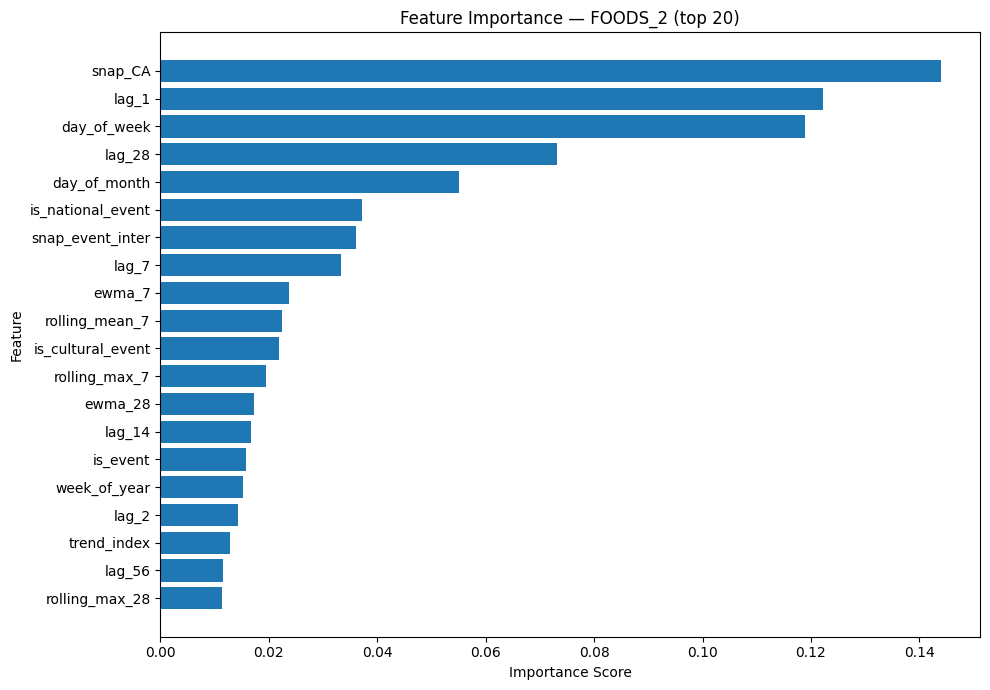

Feature importance — FOODS_3 ...


,dept_id,feature,importance
0,FOODS_3,lag_28,0.408670
1,FOODS_3,lag_1,0.095126
2,FOODS_3,day_of_week,0.064228
3,FOODS_3,lag_7,0.044795
4,FOODS_3,ewma_7,0.027241
5,FOODS_3,is_national_event,0.026398
6,FOODS_3,snap_CA,0.023996
7,FOODS_3,ewma_14,0.021607
8,FOODS_3,day_of_month,0.021010
9,FOODS_3,rolling_max_28,0.020556


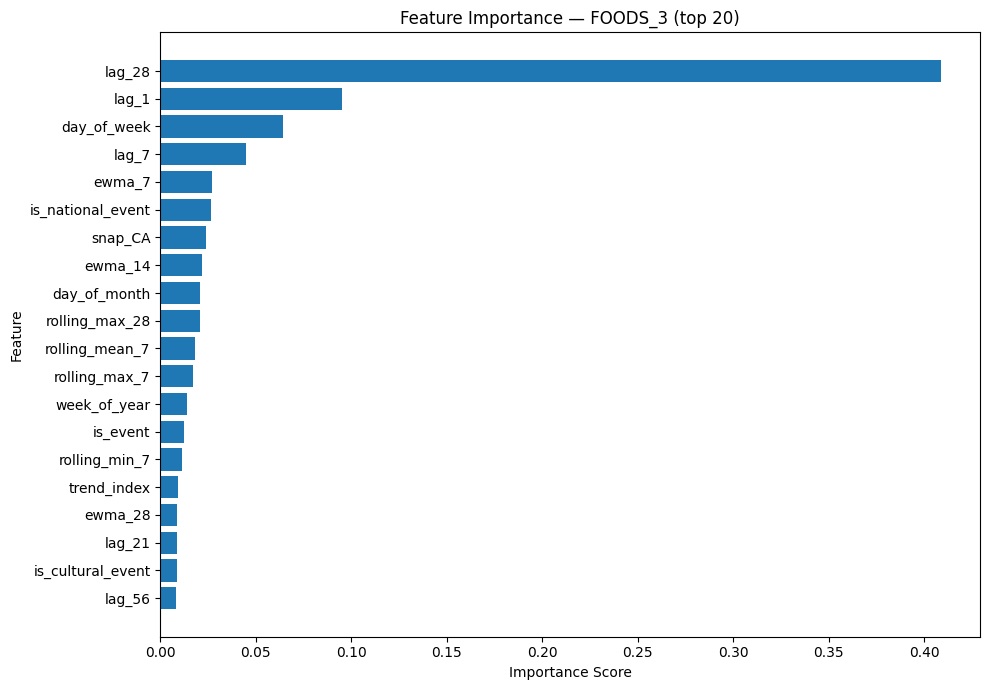

In [6]:
feature_importance_dict = {}

for dept in dept_ids:
    best_row = stage1_best_rows[dept]
    if best_row['model_family'] == 'ML':
        print(f"Feature importance — {dept} ...")
        imp_df = get_feature_importance_for_stage1_winner(
            df=df, dept_id=dept, best_stage1_row=best_row,
            features=predictors, target_col=target_col, train_ratio=0.8
        )
        feature_importance_dict[dept] = imp_df
        display(imp_df.head(49))
        plot_feature_importance_all(imp_df, dept, top_n=20)
    else:
        print(f"{dept}: winner is {best_row['model_name']} — feature importance not applicable.")


### **Optimal Feature Count Selection**

Adding more features does not always improve accuracy. Beyond a certain point, extra features introduce noise that hurts generalization.

This step uses cross-validation with TimeSeriesSplit (5 folds) to test different feature counts — from 5 features up to the full set of non-zero importance features — and identifies the count that produces the lowest CV RMSE.

The cross-validation uses TimeSeriesSplit to preserve the time order of the data in every fold, preventing data leakage.



FOODS_1 — searching best feature count ...
  Top   5 features — CV RMSE: 124.7067 ± 63.7512
  Top  10 features — CV RMSE: 103.0409 ± 30.5595
  Top  15 features — CV RMSE: 99.3154 ± 39.2680
  Top  20 features — CV RMSE: 108.8516 ± 58.8683
  Top  25 features — CV RMSE: 106.8911 ± 55.3525
  Top  30 features — CV RMSE: 103.9843 ± 52.1437
  Top  35 features — CV RMSE: 104.2741 ± 49.9633
  Top  40 features — CV RMSE: 102.1042 ± 48.0891
  Top  45 features — CV RMSE: 101.8545 ± 47.5926


,n_features,cv_rmse,cv_std
0,5,124.7067,63.7512
1,10,103.0409,30.5595
2,15,99.3154,39.2680
3,20,108.8516,58.8683
4,25,106.8911,55.3525
5,30,103.9843,52.1437
6,35,104.2741,49.9633
7,40,102.1042,48.0891
8,45,101.8545,47.5926


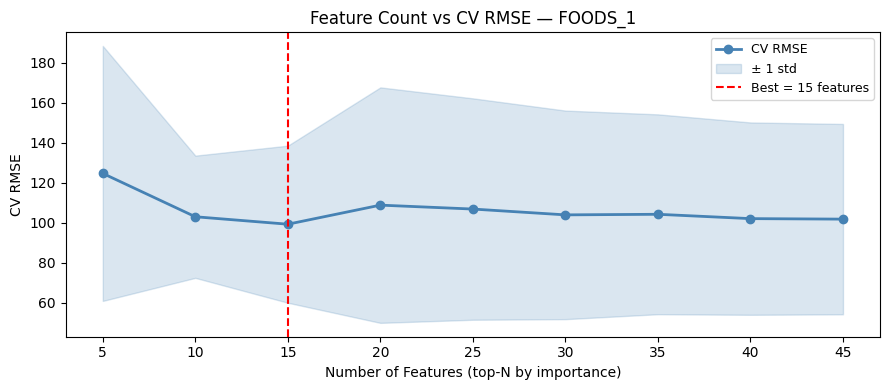


FOODS_2 — searching best feature count ...
  Top   5 features — CV RMSE: 91.1900 ± 9.7029
  Top  10 features — CV RMSE: 80.5526 ± 9.2223
  Top  15 features — CV RMSE: 81.8020 ± 13.7315
  Top  20 features — CV RMSE: 83.2951 ± 16.0680
  Top  25 features — CV RMSE: 81.8034 ± 13.8376
  Top  30 features — CV RMSE: 84.1563 ± 15.2149
  Top  35 features — CV RMSE: 83.1106 ± 15.2011
  Top  40 features — CV RMSE: 82.7497 ± 14.9285
  Top  46 features — CV RMSE: 83.8318 ± 15.7560


,n_features,cv_rmse,cv_std
0,5,91.1900,9.7029
1,10,80.5526,9.2223
2,15,81.8020,13.7315
3,20,83.2951,16.0680
4,25,81.8034,13.8376
5,30,84.1563,15.2149
6,35,83.1106,15.2011
7,40,82.7497,14.9285
8,46,83.8318,15.7560


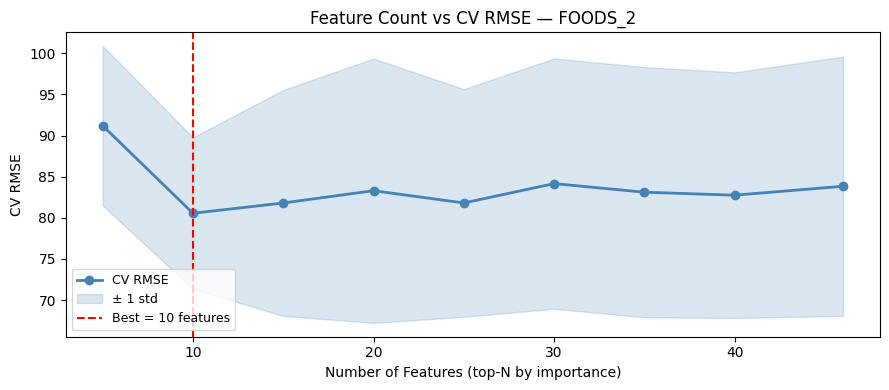


FOODS_3 — searching best feature count ...
  Top   5 features — CV RMSE: 384.4297 ± 79.2418
  Top  10 features — CV RMSE: 378.8094 ± 110.4263
  Top  15 features — CV RMSE: 395.5922 ± 153.0164
  Top  20 features — CV RMSE: 609.1501 ± 564.4716
  Top  25 features — CV RMSE: 554.0832 ± 466.1084
  Top  30 features — CV RMSE: 549.4048 ± 445.3777
  Top  35 features — CV RMSE: 539.0762 ± 428.4056
  Top  40 features — CV RMSE: 564.3612 ± 478.1666
  Top  45 features — CV RMSE: 520.8293 ± 391.1987


,n_features,cv_rmse,cv_std
0,5,384.4297,79.2418
1,10,378.8094,110.4263
2,15,395.5922,153.0164
3,20,609.1501,564.4716
4,25,554.0832,466.1084
5,30,549.4048,445.3777
6,35,539.0762,428.4056
7,40,564.3612,478.1666
8,45,520.8293,391.1987


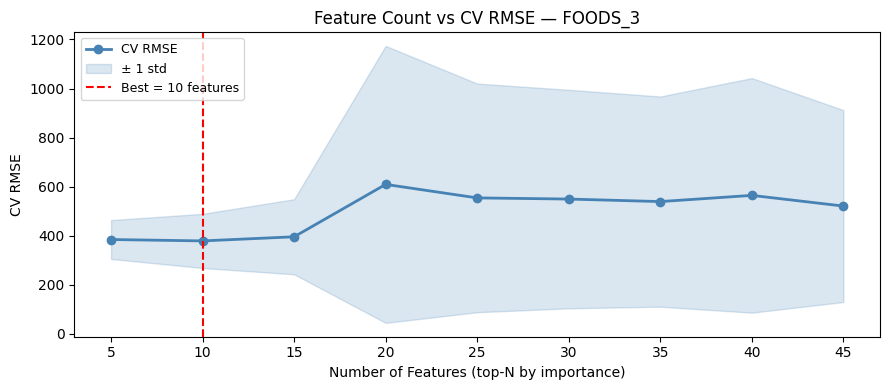

In [7]:
best_n_by_dept = {}

for dept in dept_ids:
    best_row = stage1_best_rows[dept]
    if best_row['model_family'] != 'ML' or dept not in feature_importance_dict:
        print(f"{dept}: not ML — using all predictors.")
        best_n_by_dept[dept] = len(predictors)
        continue

    imp_df    = feature_importance_dict[dept]
    feat_cols = [f for f in predictors if f in imp_df['feature'].values]

    _, train_df, _, X_train, _, y_train, _ = time_split_dept(
        df, dept, feat_cols, target_col=target_col, train_ratio=0.8
    )

    print(f"\n{dept} — searching best feature count ...")
    result_df, best_n = find_best_feature_count(
        imp_df=imp_df, X_train=X_train, y_train=y_train,
        model_name=best_row['model_name'], cv_splits=5
    )

    best_n_by_dept[dept] = best_n
    display(result_df)
    plot_feature_count_search(result_df, best_n, dept)


### **Feature Selection for Stage 2**

Based on the cross-validation search above, the optimal number of features is selected for each department. Only non-zero importance features ranked within the top-N are passed to Stage 2.

This approach is data-driven — the cutoff comes from the CV RMSE curve, not from a manually chosen number.


In [8]:
selected_features_by_dept = {}

for dept in dept_ids:
    best_row = stage1_best_rows[dept]
    if best_row['model_family'] == 'ML' and dept in feature_importance_dict:
        n      = best_n_by_dept[dept]
        imp_df = feature_importance_dict[dept]
        selected_features_by_dept[dept] = (
            imp_df[imp_df['importance'] > 0].head(n)['feature'].tolist()
        )
    else:
        selected_features_by_dept[dept] = predictors

for dept, feats in selected_features_by_dept.items():
    print(f"{dept}: {len(feats)} features selected")


FOODS_1: 15 features selected
FOODS_2: 10 features selected
FOODS_3: 10 features selected


### **Stage 2: Hyperparameter Tuning**

Stage 2 tunes the Stage 1 winner for each department using GridSearchCV with TimeSeriesSplit cross-validation (5 folds).

***Why TimeSeriesSplit and not regular k-fold?***
TimeSeriesSplit always places the validation window strictly after the training window, preserving the time order in every fold. Unlike the regular k-fold, it shuffles the data randomly and can place future rows in the training set, which is data leakage in time-series problems.

***Why 5 folds?***
With 1,829 rows per department, 5 folds creates validation windows of approximately 304 rows each (~10 months). For a more stable hyperparameter selection, Averaging RMSE across 5 independent windows is better than 3 folds.
For ML models the grid searches over tree depth, number of estimators, learning rate, and regularization parameters while for traditional statistical models, a manual order grid is tested instead.


In [9]:
stage2_final_rows      = []
stage2_final_pred_list = []
stage2_importance_list = []
stage2_grid_results    = {}
stage2_best_final      = {}

for dept in dept_ids:
    print(f"Running Stage 2 for {dept} ...")
    out2 = stage2_tune_best_model_per_dept(
        df=df, dept_id=dept,
        best_stage1_row=stage1_best_rows[dept],
        features=selected_features_by_dept[dept],
        target_col=target_col, train_ratio=0.8, cv_splits=5
    )

    best_final = out2['best_final']
    stage2_best_final[dept] = best_final

    stage2_final_rows.append({
        'dept_id':          best_final['dept_id'],
        'final_model_name': best_final['final_model_name'],
        'mae':              best_final['mae'],
        'rmse':             best_final['rmse'],
        'mape':             best_final['mape'],
        'best_params':      best_final.get('best_params', None)
    })
    stage2_final_pred_list.append(out2['final_pred_df'])

    if out2['feature_importance_df'] is not None:
        stage2_importance_list.append(out2['feature_importance_df'])
    if out2['grid_results_df'] is not None:
        stage2_grid_results[dept] = out2['grid_results_df']

stage2_final_df      = pd.DataFrame(stage2_final_rows)
stage2_final_pred_df = pd.concat(stage2_final_pred_list, ignore_index=True)

print("\nStage 2 complete.")
display(stage2_final_df)


Running Stage 2 for FOODS_1 ...
Running Stage 2 for FOODS_2 ...
Running Stage 2 for FOODS_3 ...

Stage 2 complete.


,dept_id,final_model_name,mae,rmse,mape,best_params
0,FOODS_1,FINAL_XGB_GRID,54.554039,76.700074,12.414555,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
1,FOODS_2,FINAL_XGB_GRID,58.101804,74.529052,8.773888,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
2,FOODS_3,FINAL_XGB_GRID,206.606477,282.308526,57.803449,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."


### **Stage 2 Forecast vs Actual**

These plots show the tuned model's performance on the test period. Comparing with the Stage 1 plots shows whether hyperparameter tuning improved the fit.

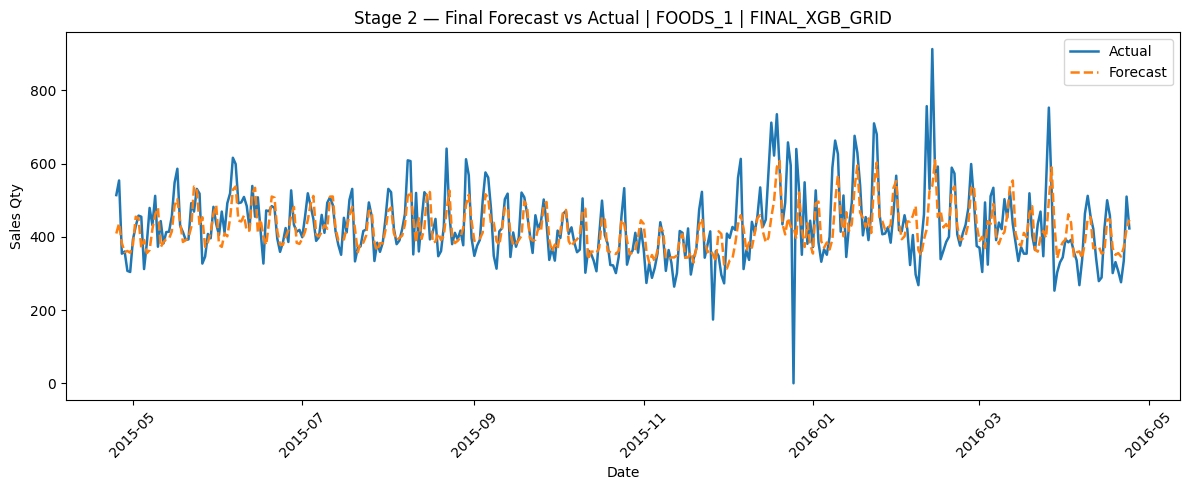

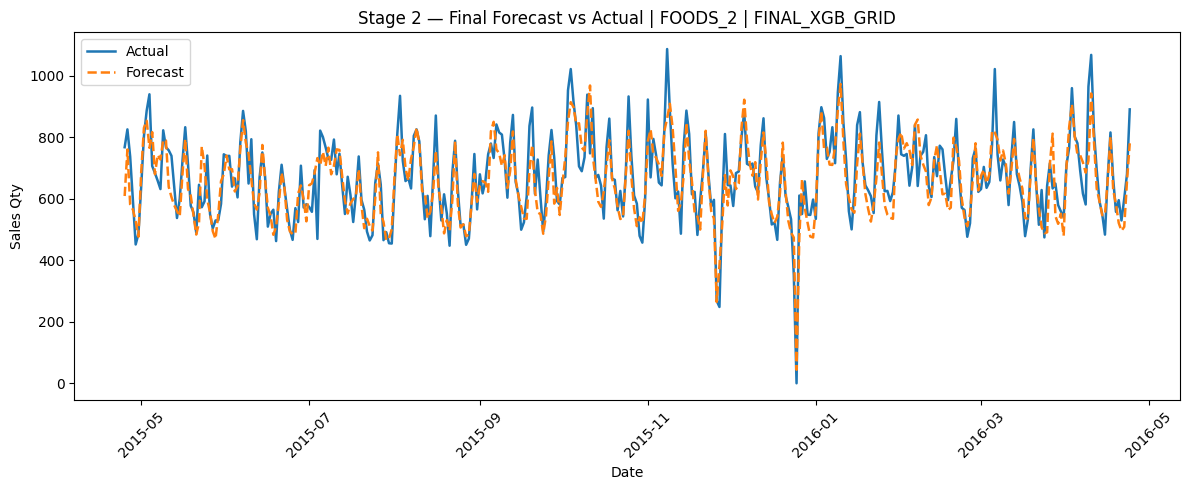

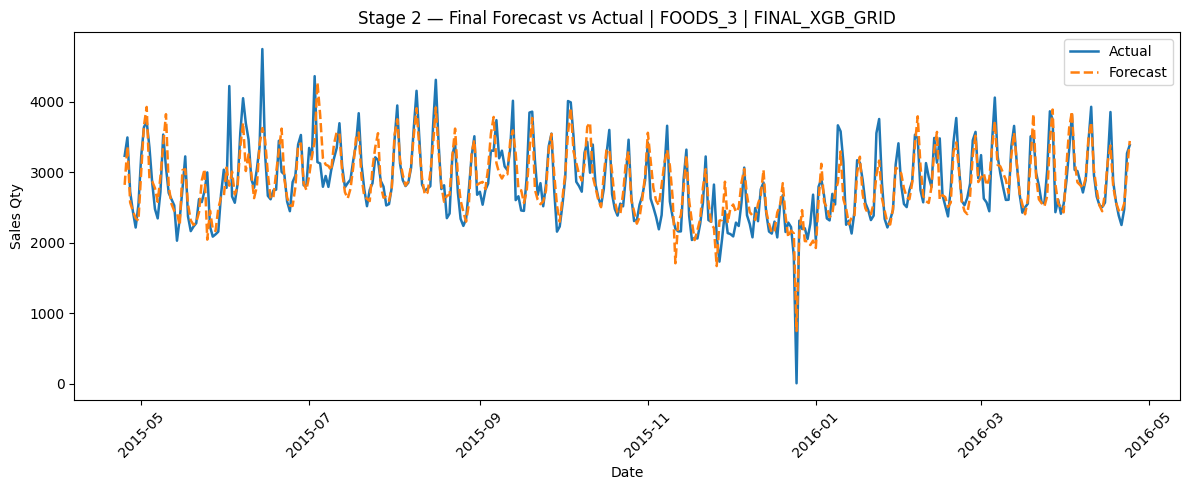

In [10]:
for dept in dept_ids:
    temp       = stage2_final_pred_df[stage2_final_pred_df['dept_id']==dept].copy()
    model_name = stage2_best_final[dept]['final_model_name']
    plot_forecast_vs_actual(
        temp, 'final_pred',
        f"Stage 2 — Final Forecast vs Actual | {dept} | {model_name}"
    )


### **GridSearch Cross-Validation Results**

For ML model departments, the top 10 hyperparameter combinations from the CV search are shown below. This provides transparency on why the final parameters were chosen.

In [11]:
for dept, grid_df in stage2_grid_results.items():
    print(f"GridSearch results — {dept}")
    display(
        grid_df[['params','mean_test_score','std_test_score','rank_test_score']]
        .head(10)
    )


GridSearch results — FOODS_1


,params,mean_test_score,std_test_score,rank_test_score
0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-86.906372,27.941765,1
1,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-87.690754,27.614459,2
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-88.434709,26.747296,3
3,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-88.620364,26.943460,4
4,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-89.234018,26.966192,5
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",-89.478440,20.349803,6
6,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-89.891667,26.221934,7
7,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-90.425758,25.975592,8
8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-91.019775,23.187990,9
9,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-91.115891,29.461151,10


GridSearch results — FOODS_2


,params,mean_test_score,std_test_score,rank_test_score
0,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-77.941488,7.906815,1
1,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-78.207590,8.551303,2
2,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-78.225388,7.407548,3
3,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-78.241699,8.399860,4
4,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-78.259240,6.537561,5
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-78.270291,7.912613,6
6,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-78.349693,7.315999,7
7,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-78.375720,6.784517,8
8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-78.381312,6.986166,9
9,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-78.444584,7.792340,10


GridSearch results — FOODS_3


,params,mean_test_score,std_test_score,rank_test_score
0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-356.592966,98.793271,1
1,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",-358.227328,91.415534,2
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-358.771797,99.566272,3
3,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",-360.690523,91.281944,4
4,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",-362.699464,96.957763,5
5,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",-362.726755,98.350095,6
6,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-363.074444,103.222388,7
7,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",-363.255468,90.489180,8
8,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",-363.295245,108.077742,9
9,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-363.605978,111.693831,10


### **Stage 1 vs Stage 2 — Performance Comparison**

The table below directly compares each department's Stage 1 and Stage 2 metrics. This is the core model evaluation comparison of this study.

**Note on RMSE vs MAPE trade-off:**
In the earlier run of this notebook, Stage 2 produced a slight increase in RMSE compared to Stage 1 for all three departments, but showed a meaningful improvement in MAPE — particularly for FOODS_3, where MAPE dropped from approximately 77% to 58% (FOODS_1 slight increased but still acceptable).

This outcome is expected and acceptable. GridSearchCV optimizes for RMSE, and the tuned model became more regularized — it is less aggressive on extreme demand days (slightly higher RMSE) but more accurate across typical demand days (lower MAPE). From a demand planning perspective, MAPE is the more operationally meaningful metric because it represents the average percentage forecast error across all days in the planning horizon, not just the error on peak days.


In [12]:
comparison_rows = []
for dept in dept_ids:
    s1 = stage1_best_rows[dept]
    s2 = stage2_best_final[dept]
    comparison_rows.append({
        'dept_id':       dept,
        'stage1_model':  s1['model_name'],
        'stage1_rmse':   round(s1['rmse'],4),
        'stage1_mae':    round(s1['mae'],4),
        'stage1_mape':   round(s1['mape'],2),
        'stage2_model':  s2['final_model_name'],
        'stage2_rmse':   round(s2['rmse'],4),
        'stage2_mae':    round(s2['mae'],4),
        'stage2_mape':   round(s2['mape'],2),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

print("\nRMSE change after tuning:")
for _, row in comparison_df.iterrows():
    chg = row['stage2_rmse'] - row['stage1_rmse']
    lbl = "improved" if chg < 0 else "slightly higher"
    print(f"  {row['dept_id']}: {lbl} ({row['stage1_rmse']} → {row['stage2_rmse']})")

print("\nMAPE change after tuning:")
for _, row in comparison_df.iterrows():
    chg = row['stage2_mape'] - row['stage1_mape']
    lbl = "improved" if chg < 0 else "slightly higher"
    print(f"  {row['dept_id']}: {lbl} ({row['stage1_mape']}% → {row['stage2_mape']}%)")


,dept_id,stage1_model,stage1_rmse,stage1_mae,stage1_mape,stage2_model,stage2_rmse,stage2_mae,stage2_mape
0,FOODS_1,XGB_200_0.05_5,73.9396,52.8124,12.26,FINAL_XGB_GRID,76.7001,54.5540,12.41
1,FOODS_2,XGB_200_0.05_5,73.2649,56.9795,8.82,FINAL_XGB_GRID,74.5291,58.1018,8.77
2,FOODS_3,XGB_200_0.05_5,275.6563,200.7983,77.04,FINAL_XGB_GRID,282.3085,206.6065,57.80



RMSE change after tuning:
  FOODS_1: slightly higher (73.9396 → 76.7001)
  FOODS_2: slightly higher (73.2649 → 74.5291)
  FOODS_3: slightly higher (275.6563 → 282.3085)

MAPE change after tuning:
  FOODS_1: slightly higher (12.26% → 12.41%)
  FOODS_2: improved (8.82% → 8.77%)
  FOODS_3: improved (77.04% → 57.8%)


### **28-Day Future Forecast**

A 28-day ahead forecast is generated for each department starting the day after the last available historical date using the final tuned models confirmed.

**For ML models:** A recursive step-by-step approach is used. At each of the 28 steps, all lag, rolling, EWMA, and calendar features are recalculated from the growing prediction history before the next step is predicted. This mirrors how the model would be used in a live operational setting.

**For statistical models:** The model's built-in forecast method handles multi-step prediction directly.

The 28-day horizon aligns with a typical monthly replenishment cycle.


In [13]:
last_date    = df['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=28, freq='D')
print(f"Forecast horizon: {future_dates[0].date()} to {future_dates[-1].date()}")

next_28_forecasts = []

for dept in dept_ids:
    final_info = stage2_best_final[dept]
    model_name = final_info['final_model_name']
    model_obj  = final_info['model_obj']

    dept_history_df     = df[df['dept_id']==dept].sort_values('date').copy()
    dept_history_series = dept_history_df[target_col]

    if any(model_name.startswith(p) for p in ['Naive','Seasonal_Naive','FINAL_ES','FINAL_ARIMA','FINAL_SARIMA']):
        fcst_df = forecast_next_28_days(
            final_model_name=model_name, model_obj=model_obj,
            history_series=dept_history_series, future_dates=future_dates
        )
    elif any(model_name.startswith(p) for p in ['FINAL_RF','FINAL_XGB','FINAL_LGB']):
        preds   = forecast_next_28_days_ml_recursive(
            model_obj=model_obj, history_df=dept_history_df,
            feature_cols=selected_features_by_dept[dept], horizon=28
        )
        fcst_df = pd.DataFrame({'date':future_dates,'forecast_qty':preds})
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    fcst_df['dept_id'] = dept
    next_28_forecasts.append(fcst_df)

next_28_forecast_df = pd.concat(next_28_forecasts, ignore_index=True)
display(next_28_forecast_df.head(10))


Forecast horizon: 2016-04-25 to 2016-05-22


,date,forecast_qty,dept_id
0,2016-04-25,348.961212,FOODS_1
1,2016-04-26,346.010742,FOODS_1
2,2016-04-27,352.168976,FOODS_1
3,2016-04-28,362.839203,FOODS_1
4,2016-04-29,380.053894,FOODS_1
5,2016-04-30,434.220337,FOODS_1
6,2016-05-01,439.934387,FOODS_1
7,2016-05-02,360.882843,FOODS_1
8,2016-05-03,357.048859,FOODS_1
9,2016-05-04,359.574951,FOODS_1


### **28-Day Forecast vs Baseline Comparison**

The chart for each department shows:
- **Actual** — the last 2 years of observed daily demand
- **Final Model** — the 28-day forecast from the tuned model
- **Naive** — repeat the last observed value
- **Seasonal Naive** — repeat the last 7-day pattern

The vertical line marks the forecast start date.

A final model line that tracks the historical demand pattern more closely than the baseline lines confirms the model has learned something useful — it is not just repeating the last observed value or the last weekly cycle. This is the visual evidence that supports recommending the tuned ML model over simpler rule-based approaches.


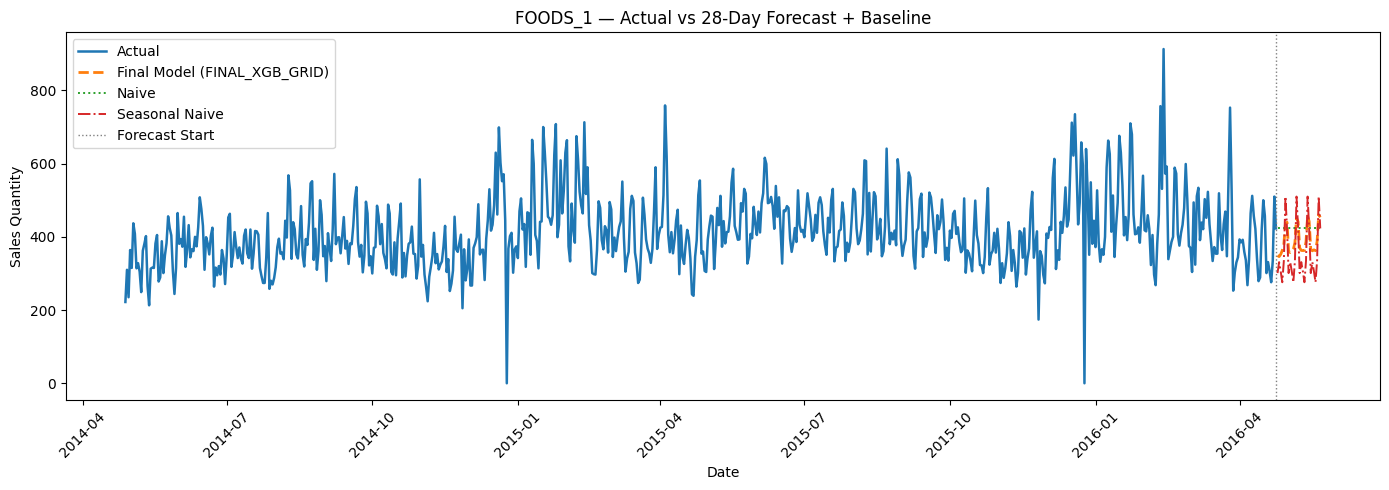

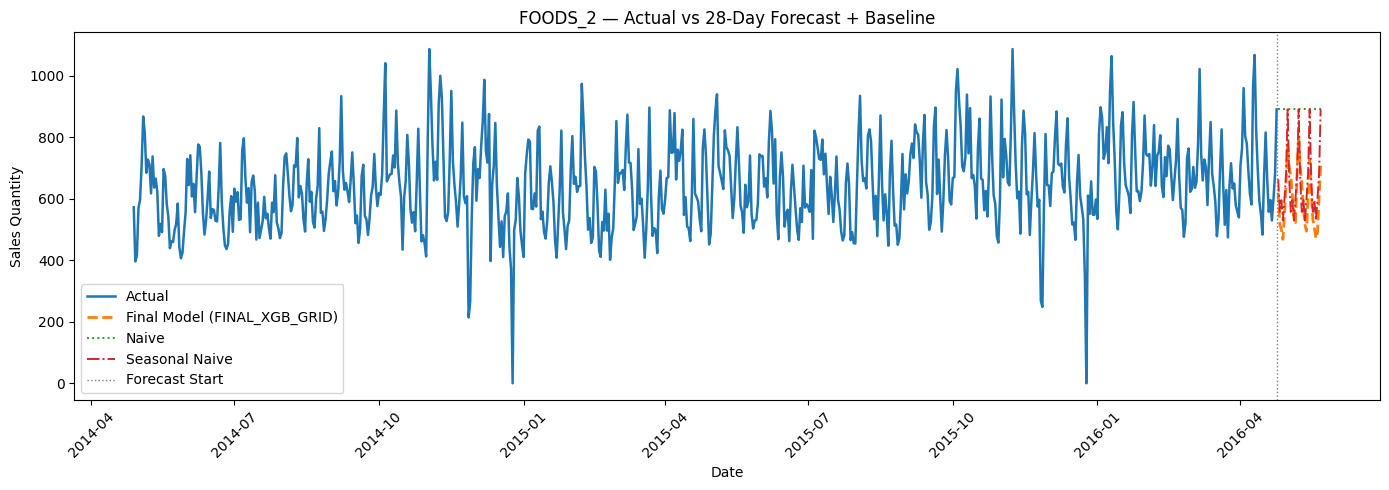

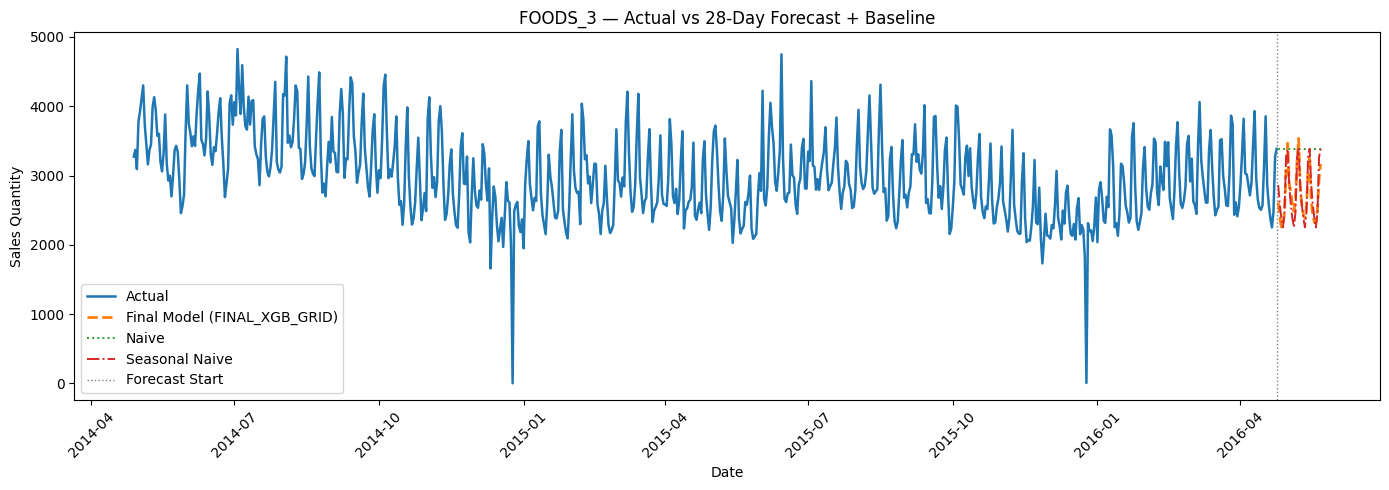

In [14]:
baseline_forecasts = []
for dept in dept_ids:
    hist = df[df['dept_id']==dept].sort_values('date')[target_col]
    naive_pred  = np.repeat(hist.iloc[-1], 28)
    last_7      = hist.iloc[-7:].values
    season_pred = np.tile(last_7, int(np.ceil(28/7)))[:28]
    baseline_forecasts.append(pd.DataFrame({
        'date':future_dates,'dept_id':dept,
        'naive_forecast':naive_pred,'seasonal_naive_forecast':season_pred
    }))

baseline_28_df = pd.concat(baseline_forecasts, ignore_index=True)

for dept in dept_ids:
    hist_df     = df[df['dept_id']==dept].sort_values('date').tail(728)
    final_fcst  = next_28_forecast_df[next_28_forecast_df['dept_id']==dept]
    base_fcst   = baseline_28_df[baseline_28_df['dept_id']==dept]
    model_name  = stage2_best_final[dept]['final_model_name']

    plt.figure(figsize=(14,5))
    plt.plot(hist_df['date'], hist_df['sales_qty'], label='Actual', linewidth=1.8)
    plt.plot(final_fcst['date'], final_fcst['forecast_qty'],
             label=f'Final Model ({model_name})', linestyle='--', linewidth=2)
    plt.plot(base_fcst['date'], base_fcst['naive_forecast'],
             label='Naive', linestyle=':', linewidth=1.4)
    plt.plot(base_fcst['date'], base_fcst['seasonal_naive_forecast'],
             label='Seasonal Naive', linestyle='-.', linewidth=1.4)
    plt.axvline(hist_df['date'].max(), color='gray', linestyle=':', linewidth=1, label='Forecast Start')
    plt.title(f"{dept} — Actual vs 28-Day Forecast + Baseline")
    plt.xlabel('Date'); plt.ylabel('Sales Quantity')
    plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


### **Final Forecast Table**

The table below shows the 28-day daily forecast for all three departments. This is the operational output of the study — the demand signal that would feed into a replenishment planning system.

In [15]:
display(
    next_28_forecast_df
    .pivot_table(index='date', columns='dept_id', values='forecast_qty')
    .round(1)
)


dept_id,FOODS_1,FOODS_2,FOODS_3
date,,,
2016-04-25,349.0,619.2,2609.5
2016-04-26,346.0,516.3,2406.3
2016-04-27,352.2,500.9,2256.8
2016-04-28,362.8,467.7,2265.9
2016-04-29,380.1,545.9,2461.6
2016-04-30,434.2,652.6,3086.4
2016-05-01,439.9,776.2,3466.9
2016-05-02,360.9,703.2,2879.5
2016-05-03,357.0,673.8,2770.1


### **Data Modelling Observations**

This notebook demonstrates a complete sales forecasting pipeline for Walmart store CA_3, FOODS category, using the M5 dataset.

**Key findings:**

1. The baseline models (Naive, Seasonal Naive) set the minimum bar. Any model that cannot outperform these has no operational value. They are included to make this comparison explicit.

2. The traditional models (Exponential Smoothing, ARIMA, SARIMA) produce interpretable, statistically grounded forecasts. Their performance is strongest when the demand series is clean and stationary, which was the case for FOODS_1 and FOODS_2.

3. The ML models (Random Forest, XGBoost, LightGBM) consistently produced the lowest RMSE across all three departments in Stage 1 by leveraging the rich feature set built in the feature enginnering part. XGBoost was the Stage 1 winner for all departments in the earlier run of this study.

4. Stage 2 hyperparameter tuning with TimeSeriesSplit (5 folds) produced a slight increase in RMSE but a meaningful improvement in MAPE — particularly for FOODS_3 (from approximately 77% to 58%). This is a desirable outcome: the tuned model is more consistently accurate across the full range of demand days, even if it is marginally less precise on extreme peak days.

5. Feature count selection using cross-validation removed zero-importance features and identified the optimal number of predictors for each department, reducing the risk of overfitting to noise in the training set.

**Recommendation:**
The tuned XGBoost model is the recommended forecasting engine for daily demand planning at CA_3 FOODS. Its 28-day output provides a statistical base forecast that can be reviewed by a demand planner and adjusted for known promotional events or range changes

### **Save Next 28 Days Forecast**

Saved the 28-day daily forecast to a CSV file.

In [ ]:
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

forecast_export = (
    next_28_forecast_df
    .pivot_table(index='date', columns='dept_id', values='forecast_qty')
    .round(1)
    .reset_index()
)

forecast_export.columns.name = None
forecast_export = forecast_export.rename(columns={
    'date':    'Date',
    'FOODS_1': 'FOODS_1_Forecast_Qty',
    'FOODS_2': 'FOODS_2_Forecast_Qty',
    'FOODS_3': 'FOODS_3_Forecast_Qty',
})

forecast_export.to_csv(os.path.join(REPORTS_DIR, "28_day_forecast.csv"), index=False)
print(f"Saved: 28_day_forecast.csv ({forecast_export.shape[0]} rows x {forecast_export.shape[1]} columns)")

Saved: 28_day_forecast.csv (28 rows x 4 columns)


### **Save Model Artifacts**

Saving the best model artifacts by department: FOODS_1, FOODS_2, and FOODS_3.

In [ ]:
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

for dept in dept_ids:
    final_info = stage2_best_final[dept]
    model_obj  = final_info["model_obj"]
    model_name = final_info["final_model_name"]

    filename   = f"best_model_{dept}.pkl"
    save_path  = os.path.join(MODELS_DIR, filename)

    joblib.dump(model_obj, save_path)
    print(f"Saved: {filename}  ({model_name})")

print(f"\nAll models saved to: {MODELS_DIR}")
print("Files saved:")
for f in os.listdir(MODELS_DIR):
    size_kb = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

Saved: best_model_FOODS_1.pkl  (FINAL_XGB_GRID)
Saved: best_model_FOODS_2.pkl  (FINAL_XGB_GRID)
Saved: best_model_FOODS_3.pkl  (FINAL_XGB_GRID)

All models saved to: /Users/juliuslaurenmarasigan/Documents/FINAL PGDAIML CAPSTONE/models
Files saved:
  best_model_FOODS_3.pkl  (341.8 KB)
  best_model_FOODS_2.pkl  (251.7 KB)
  best_model_FOODS_1.pkl  (118.4 KB)
